# 🍳 Claudia Recipe Dataset Analysis

This notebook provides a comprehensive analysis of the recipe dataset from Kaggle. We'll explore data quality, distributions, patterns, and derive insights for the Claudia recipe platform.

## Overview
- **Dataset**: recipes_data.csv
- **Purpose**: Exploratory Data Analysis (EDA) and data quality assessment
- **Output**: Insights for ETL pipeline improvements

## 1. Import Required Libraries

Import all necessary libraries for data analysis and visualization.

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load the Dataset

Load the recipe data from the CSV file and display initial preview.

In [3]:
# Load the dataset
data_path = 'raw/recipes_data.csv'

try:
    df = pd.read_csv(data_path)
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
except FileNotFoundError:
    print(f"❌ Error: File not found at {data_path}")
    print("Please ensure the CSV file is in the correct location.")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

✅ Dataset loaded successfully!
📊 Shape: 2,231,142 rows × 7 columns


In [4]:
# Display first rows
print("📋 First 5 rows of the dataset:\n")
df.head()

📋 First 5 rows of the dataset:



,title,ingredients,directions,link,source,NER,site
0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""bite size shredded rice biscuits"", ""vanilla""...",www.cookbooks.com
1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""cream of mushroom soup"", ""beef"", ""sour cream...",www.cookbooks.com
2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""pepper"", ""cream cheese"", ""gar...",www.cookbooks.com
3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken gravy"", ""cream of mushroom soup"", ""c...",www.cookbooks.com
4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""graham cracker crumbs"", ""powdered sugar"", ""p...",www.cookbooks.com


## 3. Display Basic Dataset Information

Examine column names, data types, and memory usage.

In [5]:
# Dataset information
print("📊 Dataset Information:\n")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
print(f"\n📝 Column Names and Types:")
print(df.dtypes)
print(f"\n💾 Memory Usage:")
print(df.memory_usage(deep=True))

📊 Dataset Information:

Number of rows: 2,231,142
Number of columns: 7

📝 Column Names and Types:
title          object
ingredients    object
directions     object
link           object
source         object
NER            object
site           object
dtype: object

💾 Memory Usage:
Index                 132
title           163156232
ingredients     687066695
directions     1236297932
link            228337412
source          127763138
NER             352891256
site            144279082
dtype: int64


In [6]:
# Detailed info
print("\n📋 Detailed Dataset Info:")
df.info()


📋 Detailed Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2231142 entries, 0 to 2231141
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   title        object
 1   ingredients  object
 2   directions   object
 3   link         object
 4   source       object
 5   NER          object
 6   site         object
dtypes: object(7)
memory usage: 119.2+ MB


## 4. Check for Missing Values

Identify and visualize missing data patterns.

In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("🔍 Missing Values Summary:\n")
print(missing_df[missing_df['Missing Values'] > 0])

if missing_df['Missing Values'].sum() == 0:
    print("\n✅ No missing values found!")

🔍 Missing Values Summary:

       Missing Values  Percentage
title               1    0.000045


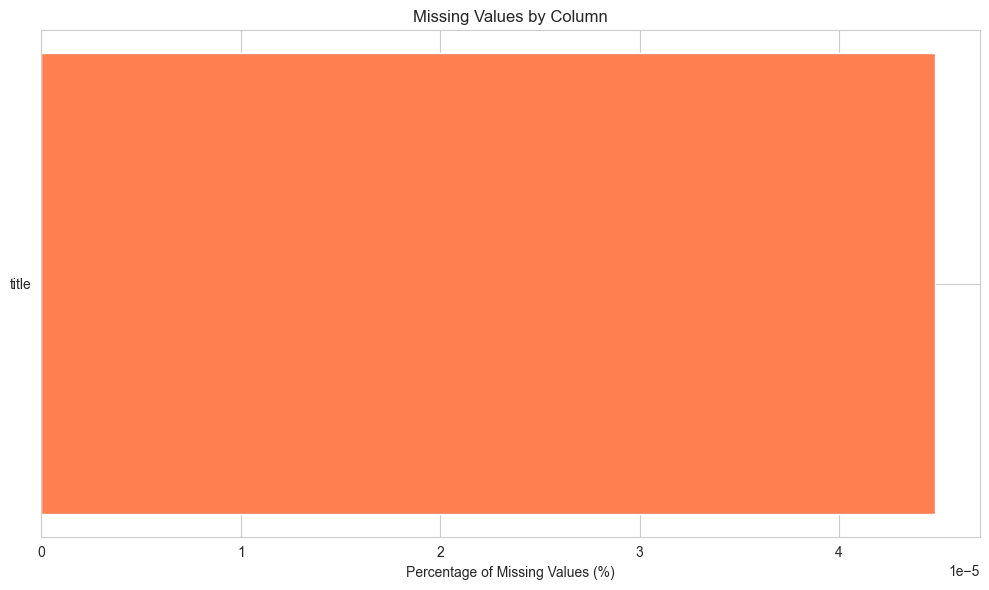

In [8]:
# Visualize missing values
if missing_df['Missing Values'].sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_data = missing_df[missing_df['Missing Values'] > 0]
    plt.barh(missing_data.index, missing_data['Percentage'], color='coral')
    plt.xlabel('Percentage of Missing Values (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print("✨ No missing values to visualize!")

##5. Generate Descriptive Statistics

Calculate summary statistics for numerical and categorical columns.

In [9]:
# Descriptive statistics for numerical columns
print("📊 Descriptive Statistics (Numerical Columns):\n")
df.describe()

📊 Descriptive Statistics (Numerical Columns):



,title,ingredients,directions,link,source,NER,site
count,2231141,2231142,2231142,2231142,2231142,2231142,2231142
unique,1312870,2226362,2211644,2231142,2,2004769,28
top,Chicken Casserole,"[""1 c. peanut butter"", ""1 c. sugar"", ""1 egg""]","[""Mix all ingredients together.""]",www.foodandwine.com/recipes/polpette-spicy-tom...,Gathered,[],www.cookbooks.com
freq,4099,28,274,1,1643098,573,896341


In [10]:
# Descriptive statistics for categorical columns
print("📋 Descriptive Statistics (Categorical Columns):\n")
df.describe(include='object')

📋 Descriptive Statistics (Categorical Columns):



,title,ingredients,directions,link,source,NER,site
count,2231141,2231142,2231142,2231142,2231142,2231142,2231142
unique,1312870,2226362,2211644,2231142,2,2004769,28
top,Chicken Casserole,"[""1 c. peanut butter"", ""1 c. sugar"", ""1 egg""]","[""Mix all ingredients together.""]",www.foodandwine.com/recipes/polpette-spicy-tom...,Gathered,[],www.cookbooks.com
freq,4099,28,274,1,1643098,573,896341


In [11]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate Rows: {duplicates:,}")
if duplicates > 0:
    print(f"⚠️  {duplicates} duplicate rows found!")
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("✅ No duplicate rows found!")


🔄 Duplicate Rows: 0
✅ No duplicate rows found!


## 6. Visualize Data Distribution

Explore the distribution of numerical features through histograms and plots.

In [12]:
# Plot distributions for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
            axes[idx].set_title(f'Distribution of {col}')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
    
    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns to visualize.")

No numerical columns to visualize.


## 7. Explore Correlations

Calculate correlation between numerical features and visualize with a heatmap.

In [13]:
# Correlation matrix
if len(numerical_cols) > 1:
    correlation = df[numerical_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, fmt='.2f')
    plt.title('Correlation Heatmap - Numerical Features')
    plt.tight_layout()
    plt.show()
    
    print("\n🔗 Strongest Correlations:")
    # Get correlations and sort
    corr_pairs = correlation.unstack()
    corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations
    print(corr_pairs.sort_values(ascending=False).head(10))
else:
    print("Not enough numerical columns for correlation analysis.")

Not enough numerical columns for correlation analysis.


## 8. Identify Outliers

Use box plots to detect outliers in numerical features.

In [14]:
# Box plots for outlier detection
if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            df.boxplot(column=col, ax=axes[idx])
            axes[idx].set_title(f'Box Plot - {col}')
            axes[idx].set_ylabel(col)
    
    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns for outlier detection.")

No numerical columns for outlier detection.


## 9. Recipe-Specific Analysis

Explore recipe categories, cuisines, difficulty levels, and other categorical features.

In [15]:
# Analyze categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("📋 Categorical Columns Analysis:\n")
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  - Unique values: {df[col].nunique()}")
    print(f"  - Top 5 values:")
    print(df[col].value_counts().head())

📋 Categorical Columns Analysis:


title:
  - Unique values: 1312870
  - Top 5 values:
title
Chicken Casserole     4099
Broccoli Casserole    3985
Squash Casserole      2508
Cheese Ball           2426
Zucchini Bread        2298
Name: count, dtype: int64

ingredients:
  - Unique values: 2226362
  - Top 5 values:
ingredients
["1 c. peanut butter", "1 c. sugar", "1 egg"]                      28
["1 c. peanut butter", "1 c. sugar", "1 egg", "1 tsp. vanilla"]    22
["Ingredients:"]                                                   21
["1 box yellow cake mix"]                                          18
["1 cup sugar", "1 cup water"]                                     15
Name: count, dtype: int64

directions:
  - Unique values: 2211644
  - Top 5 values:
directions
["Mix all ingredients together."]                              274
["Put ingredients into bread machine and press \"Start\"."]    234
["Mix together and chill."]                                    182
["Mix all ingredients together

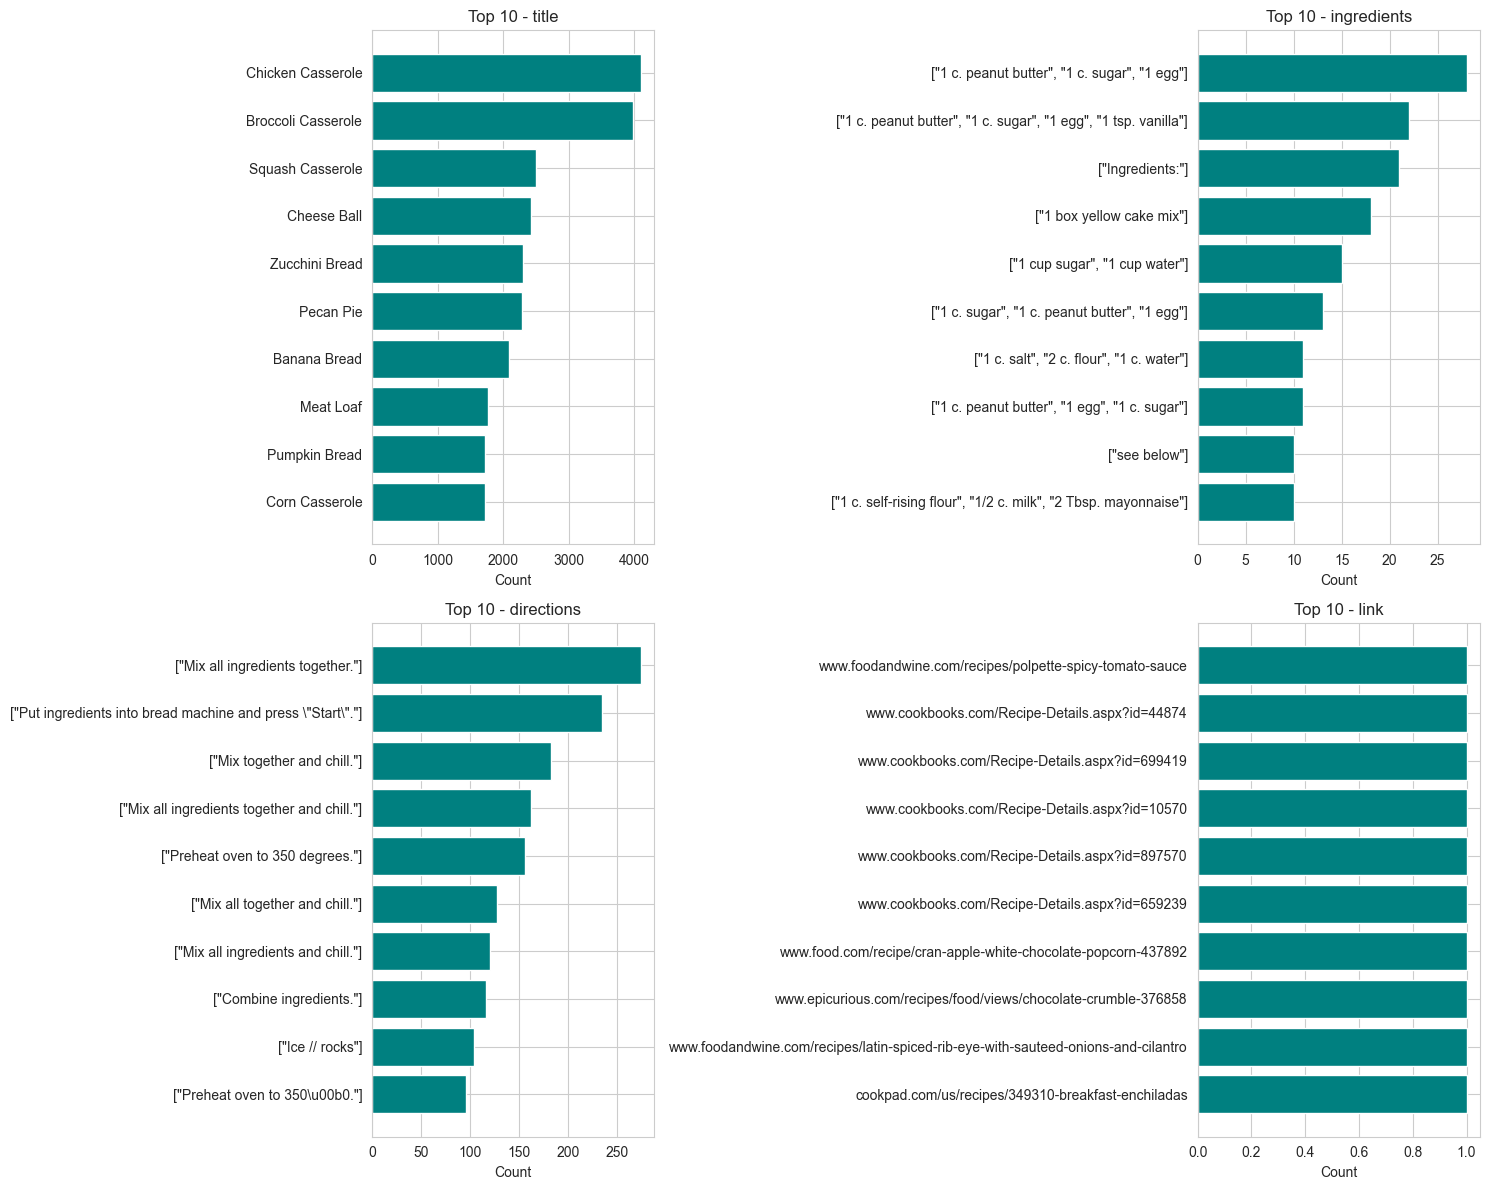

In [16]:
# Visualize top categorical values
if len(categorical_cols) > 0:
    n_plots = min(4, len(categorical_cols))
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols[:n_plots]):
        top_values = df[col].value_counts().head(10)
        axes[idx].barh(range(len(top_values)), top_values.values, color='teal')
        axes[idx].set_yticks(range(len(top_values)))
        axes[idx].set_yticklabels(top_values.index)
        axes[idx].set_xlabel('Count')
        axes[idx].set_title(f'Top 10 - {col}')
        axes[idx].invert_yaxis()
    
    # Hide unused subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns to visualize.")

## 10. Data Quality Summary & Recommendations

Summary of findings and recommendations for ETL pipeline improvements.

In [17]:
# Data Quality Summary
print("=" * 70)
print("📊 DATA QUALITY SUMMARY")
print("=" * 70)

print(f"\n✅ Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"✅ Total Columns: {len(df.columns)}")
print(f"   - Numerical: {len(numerical_cols)}")
print(f"   - Categorical: {len(categorical_cols)}")

missing_total = df.isnull().sum().sum()
print(f"\n{'⚠️ ' if missing_total > 0 else '✅'} Missing Values: {missing_total:,} ({(missing_total / (df.shape[0] * df.shape[1]) * 100):.2f}%)")

duplicates = df.duplicated().sum()
print(f"{'⚠️ ' if duplicates > 0 else '✅'} Duplicate Rows: {duplicates:,}")

print("\n" + "=" * 70)
print("💡 RECOMMENDATIONS FOR ETL PIPELINE")
print("=" * 70)

recommendations = [
    "1. Handle missing values: Implement imputation or filtering strategies",
    "2. Remove duplicates: Add deduplication step in ETL process",
    "3. Standardize formats: Ensure consistent data types and formats",
    "4. Validate data: Add validation rules for critical fields",
    "5. Handle outliers: Implement outlier detection and treatment",
    "6. Enrich data: Consider adding derived fields (e.g., total time)",
    "7. Categorize properly: Standardize category and cuisine names",
    "8. Document schema: Create clear data dictionary for all fields"
]

for rec in recommendations:
    print(f"\n{rec}")

print("\n" + "=" * 70)
print("🎯 Next Steps: Use these insights to refine your ETL script!")
print("=" * 70)

📊 DATA QUALITY SUMMARY

✅ Dataset Shape: 2,231,142 rows × 7 columns
✅ Total Columns: 7
   - Numerical: 0
   - Categorical: 7

⚠️  Missing Values: 1 (0.00%)
✅ Duplicate Rows: 0

💡 RECOMMENDATIONS FOR ETL PIPELINE

1. Handle missing values: Implement imputation or filtering strategies

2. Remove duplicates: Add deduplication step in ETL process

3. Standardize formats: Ensure consistent data types and formats

4. Validate data: Add validation rules for critical fields

5. Handle outliers: Implement outlier detection and treatment

6. Enrich data: Consider adding derived fields (e.g., total time)

7. Categorize properly: Standardize category and cuisine names

8. Document schema: Create clear data dictionary for all fields

🎯 Next Steps: Use these insights to refine your ETL script!
